# Velocity from gravity-free acceleration

This is the final goal of the pipeline. 

Velocity/speed satisfies the following equation:
$$
\frac{d\mathbf{v}}{dt} = \mathbf{a}(t)
$$
One could try to view this problem in two (related) ways: as an ODE (ordinary differential equation) or as an integration problem. 

Viewing it as an ODE, there are some issues. Most (if not all) methods (Runge-Kutta, multistep) assume an available function of the independent and dependent variables that can be evaluated at different places. This isn't my case: I only have measurements, and I don't have a physical models of calisthenics exercises either. Trying to apply ODE methods anyway would necessarily need some form of curve fitting (e.g. regression, splines) prior to actually running the ODE method itself. This is obviously not viable for a device that has to run real-time on constrainted resources.   

Viewing it as an integration problem, applying the fundamental theorem of calculus, we have:

$$
\int_{t_i}^{t_i+1} d\mathbf{v} = \int_{t_i}^{t_i+1} \mathbf{a}(t) dt \newline
v_{x, t_i+1} = v_{x, t_i} + \int_{t_i}^{t_i+1} a_x(t) dt \newline
v_{y, t_i+1} = v_{y, t_i} + \int_{t_i}^{t_i+1} a_y(t) dt \newline
v_{z, t_i+1} = v_{z, t_i} + \int_{t_i}^{t_i+1} a_z(t) dt \newline
$$
This is a much simpler problem, since for $\mathbf{a}(t)$ I can just apply well-known numerical integration formulas (Newton-Cotes, Adams-Moulton). The best method is the one that gives the best results with the least computational cost.

Sources:
* [Numerical methods for engineers](../../docs/misc/Numerical%20Methods%20for%20Engineers%20(7ed)%20-%20Chapra,%20Canale.pdf). Chapters 21, 25, 26.

## Setup

In [1]:
from signal_utils import IMUSampleReader, IMUStationaryChecker, IMUSampleWriter
from scipy import integrate, stats
import numpy as np
import matplotlib.pyplot as plt

SAMPLING_FREQUENCY = 30  # Hz
dt = 1 / SAMPLING_FREQUENCY

sixFaceStationaryCaptures = [
    "../4-gravityRemoval/output/neg-x-up-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/pos-x-up-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/neg-y-up-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/pos-y-up-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/neg-z-up-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/pos-z-up-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl-g-free-rot-mat.csv",
]
tiltedStationaryCaptures = [
    "../4-gravityRemoval/output/pos-x-pos-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/neg-x-pos-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/pos-y-pos-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/neg-y-pos-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/pos-x-neg-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/neg-x-neg-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/pos-y-neg-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/neg-y-neg-z-tilt-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl-g-free-rot-mat.csv",
]
stationaryCaptures = [*sixFaceStationaryCaptures, *tiltedStationaryCaptures]

simpleRotationsCaptures = [
    "../4-gravityRemoval/output/rot-x-hw-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/rot-y-hw-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/rot-z-hw-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl-g-free-rot-mat.csv",
]

exerciseCaptures = [
    "../4-gravityRemoval/output/dips-1-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/dips-2-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/dips-3-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/pull-ups-1-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/pull-ups-2-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/pull-ups-3-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/90-deg-push-ups-1-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/90-deg-push-ups-2-calib-affine-sixf-tilted-a-online-w-filt-box5-or-compl-g-free-rot-mat.csv",
]


stationaryChecker = IMUStationaryChecker()
stationaryChecker.computeTolerances(stationaryCaptures)

reader = IMUSampleReader()
writer = IMUSampleWriter()


def cumulativeEuler(dy, x, dx):
    result = np.zeros_like(dy)
    for i in range(1, len(dy)):
        result[i] = result[i - 1] + dy[i - 1] * dx
    return result


def cumulativeClosedAdams3(dy, x, dx):
    result = np.zeros_like(dy)
    result[1] = (dy[0] + dy[1]) * dx / 2  # Trapezoid rule for the first step
    for i in range(2, len(dy)):
        result[i] = result[i - 1] + (dx / 12) * (5 * dy[i] + 8 * dy[i - 1] - dy[i - 2])
    return result


def computeErrors(trueValues, estimatedValues):
    errors = trueValues - estimatedValues
    rmse = np.sqrt(np.mean(errors**2))
    return (errors, rmse)


def plotODESolutions(axis, title, x, dx, x0, y, dy, y0):
    eulerSol = y0 + cumulativeEuler(dy, x=x, dx=dx)
    trapSol = y0 + integrate.cumulative_trapezoid(dy, x=x, dx=dx, initial=0)
    adams3Sol = y0 + cumulativeClosedAdams3(dy, x=x, dx=dx)
    simpsonSol = y0 + integrate.cumulative_simpson(dy, x=x, dx=dx, initial=0)

    errorsEuler, rmsEuler = computeErrors(y, eulerSol)
    errorsTrap, rmsTrap = computeErrors(y, trapSol)
    errorsAdams3, rmsAdams3 = computeErrors(y, adams3Sol)
    errorsSimpson, rmsSimpson = computeErrors(y, simpsonSol)

    axis.set_title(title)
    axis.plot(x, y, label="Analytical", color="red")
    axis.plot(
        x,
        eulerSol,
        label=f"Euler (RMSE={rmsEuler:.2e}, maxE={np.max(errorsEuler):.2e})",
        color="blue",
    )
    axis.plot(
        x,
        trapSol,
        label=f"Trapezoid (RMSE={rmsTrap:.2e}, maxE={np.max(errorsTrap):.2e})",
        color="green",
    )
    axis.plot(
        x,
        adams3Sol,
        label=f"Adams 3 (RMSE={rmsAdams3:.2e}, maxE={np.max(errorsAdams3):.2e})",
        color="purple",
    )
    axis.plot(
        x,
        simpsonSol,
        label=f"Simpson (RMSE={rmsSimpson:.2e}, maxE={np.max(errorsSimpson):.2e})",
        color="orange",
    )
    axis.legend(fontsize=8)
    axis.grid()

Acceleration norms:
	Mean = 0.078534
	Stdev = 0.050109 (tol = 0.150327)
	Stationary interval = [-0.071793, 0.228861]
Gyroscope norms:
	Mean = 0.141652
	Stdev = 1.273801 (tol = 3.821403)
	Stationary interval = [-3.679752, 3.963055]


## Simple ODE with known solution
*Equation*: 
$\frac{dy}{dx} = -2x^3 + 12x^2 -20x+8.5, \text{ with } y(0) = 1$

*Conclusion*: 
* Euler is just bad ($O(h)$). It would only work well with very small step sizes and small integration windows. Don't use it if possible.
* The other ones tend to cluster together: Simpson ($O(h^4)$) is better than Adams3 ($O(h^3)$), which in turn is better than Trapezoid ($O(h^2)$).
* On the device, Simpson would need a different implementation. Samples come as a stream, and only one is processed at a time. The solution would need to be provided every two samples, and I would need to be careful of not integrating the same sample twice. Adams-Moulton formulas are a better fit, since they use previous points to fit a polynomial but only integrate on the last interval.
* Higher order polynomials are probably not worth it.

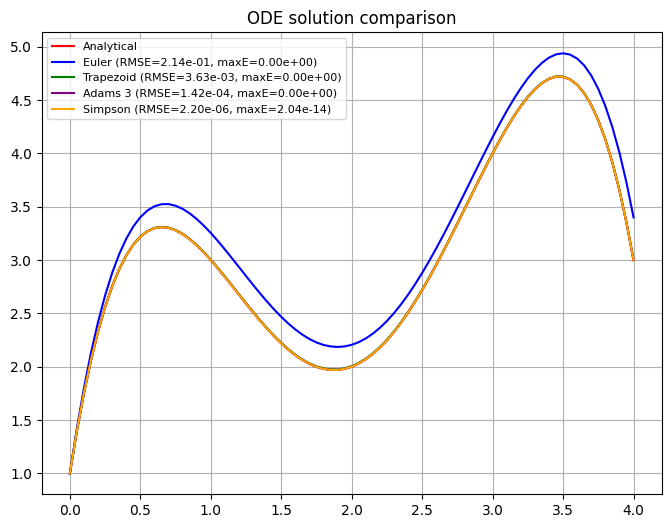

In [2]:
lowerBound = 0
upperBound = 4
dt = 0.05
t = np.arange(lowerBound, upperBound + dt, dt)
a = -2 * t**3 + 12 * t**2 - 20 * t + 8.5
x0 = 0
y0 = 1
v = -0.5 * t**4 + 4 * t**3 - 10 * t**2 + 8.5 * t + 1

fig, axes = plt.subplots(figsize=(8, 6))
plotODESolutions(axes, "ODE solution comparison", t, dt, x0, v, a, y0)
plt.show()

## ODE with various error sources

**General conclusion** (see below for details): 

The more imperfect the input is, the less the integration method or theoretical order matters. The only concession is not to choose Euler if possible, which is the only one that is consistently worse than the others. Focus more on mitigating noise, bias, drift and sampling jitter. 

**Choosen method**:

Trapezoid. The cheapest of the "good" ones, streaming-friendly.

### Noise

Normally distributed noise is chosen because it's the most common type. As a stress-test another, more pathological distribution (e.g. Cauchy) could be tried out later. 

*Conclusion*:

The more the signal is buried in noise, the less the integration method matters. However, Euler still performs worse than the others. Increasing the step size tends to help.

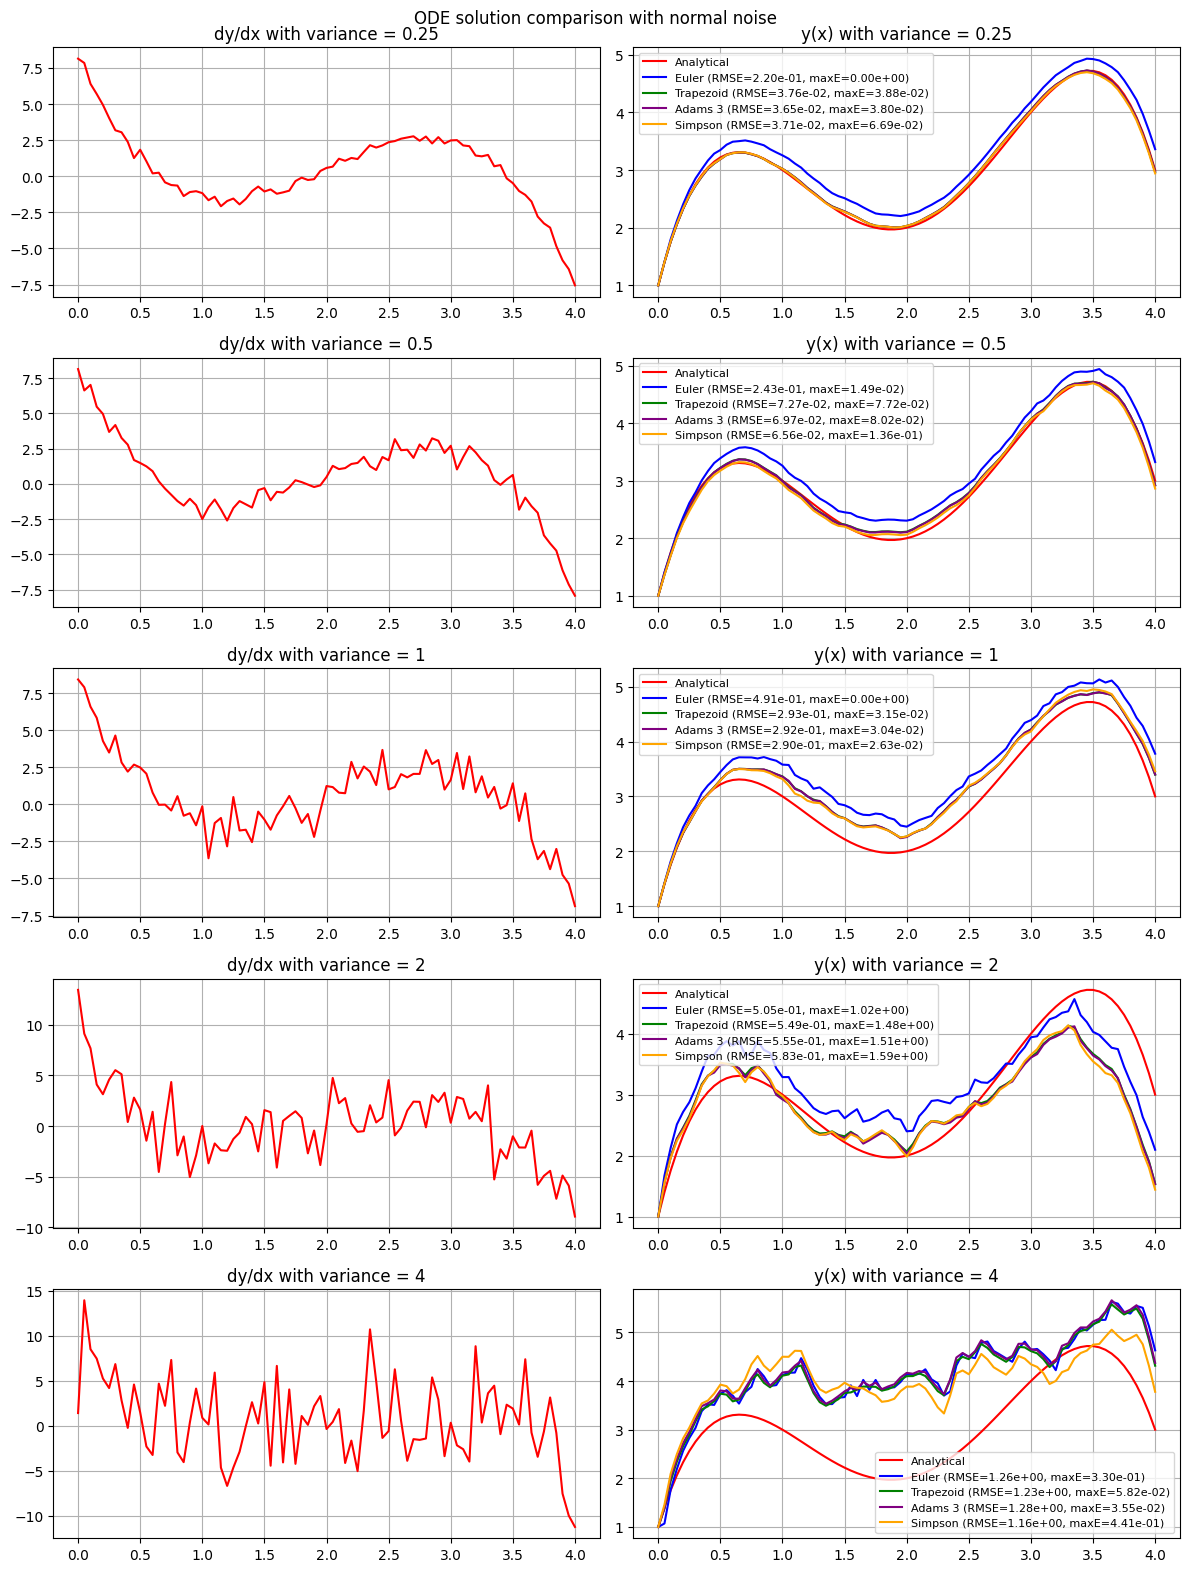

In [3]:
seed = 12345  # Use always the same seed for reproducibility
rng = np.random.default_rng(seed)
vars = [0.25, 0.5, 1, 2, 4]
fig, axes = plt.subplots(len(vars), 2, figsize=(12, 16))
fig.suptitle("ODE solution comparison with normal noise")
for j, var in enumerate(vars):
    dyBiased = a + stats.norm.rvs(loc=0, scale=var, size=len(a), random_state=rng)
    axes[j, 0].plot(t, dyBiased, color="red")
    axes[j, 0].set_title(f"dy/dx with variance = {var}")
    axes[j, 0].grid()
    plotODESolutions(
        axes[j, 1], f"y(x) with variance = {var}", t, dt, x0, v, dyBiased, y0
    )
fig.tight_layout()
plt.show()

### Bias

Bias is modeled as a constant offset to the signal.

*Conclusion*:

Even small biases can make the integration diverge from the true solution.

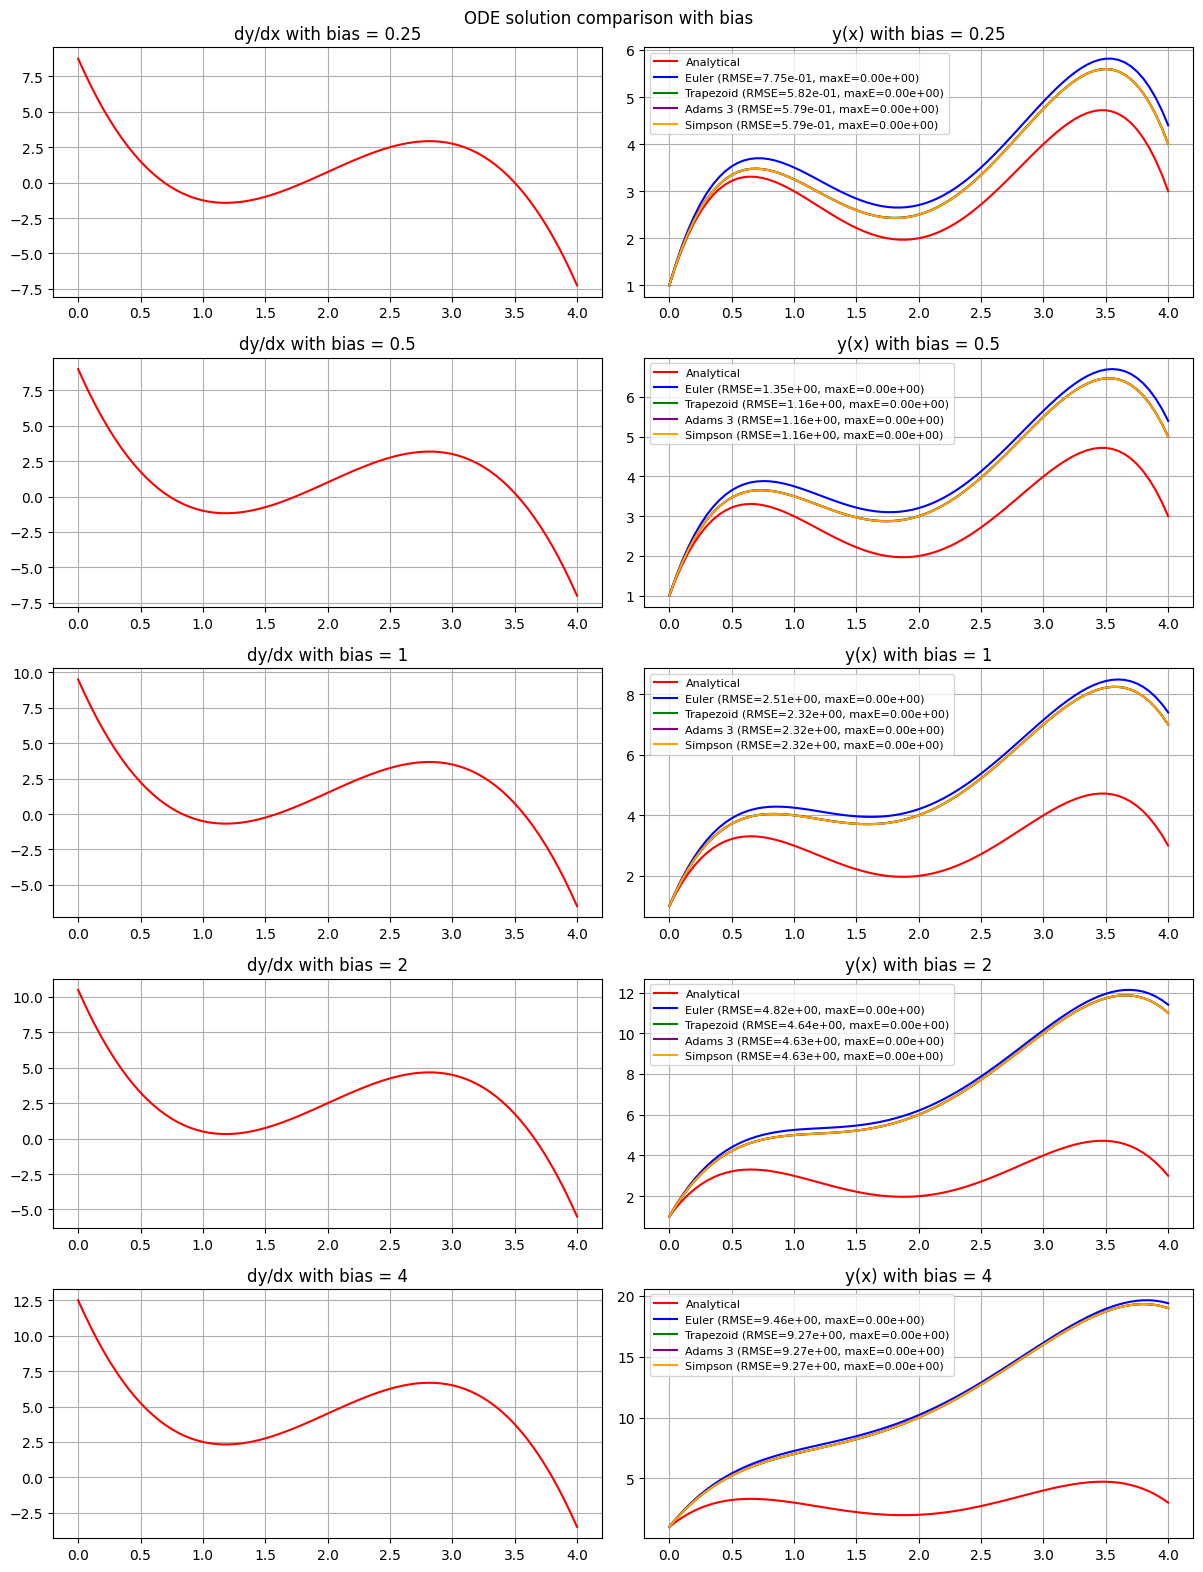

In [4]:
biases = [0.25, 0.5, 1, 2, 4]
fig, axes = plt.subplots(len(biases), 2, figsize=(12, 16))
fig.suptitle("ODE solution comparison with bias")
for j, bias in enumerate(biases):
    dyBiased = a + bias
    axes[j, 0].plot(t, dyBiased, color="red")
    axes[j, 0].set_title(f"dy/dx with bias = {bias}")
    axes[j, 0].grid()
    plotODESolutions(axes[j, 1], f"y(x) with bias = {bias}", t, dt, x0, v, dyBiased, y0)
fig.tight_layout()
plt.show()

### Drift

Drift is modeled just as a linear function of time with a small slope and bias = 0.

*Conclusion*:

Unless the drift is very small, it will make the integration diverge from the true solution.

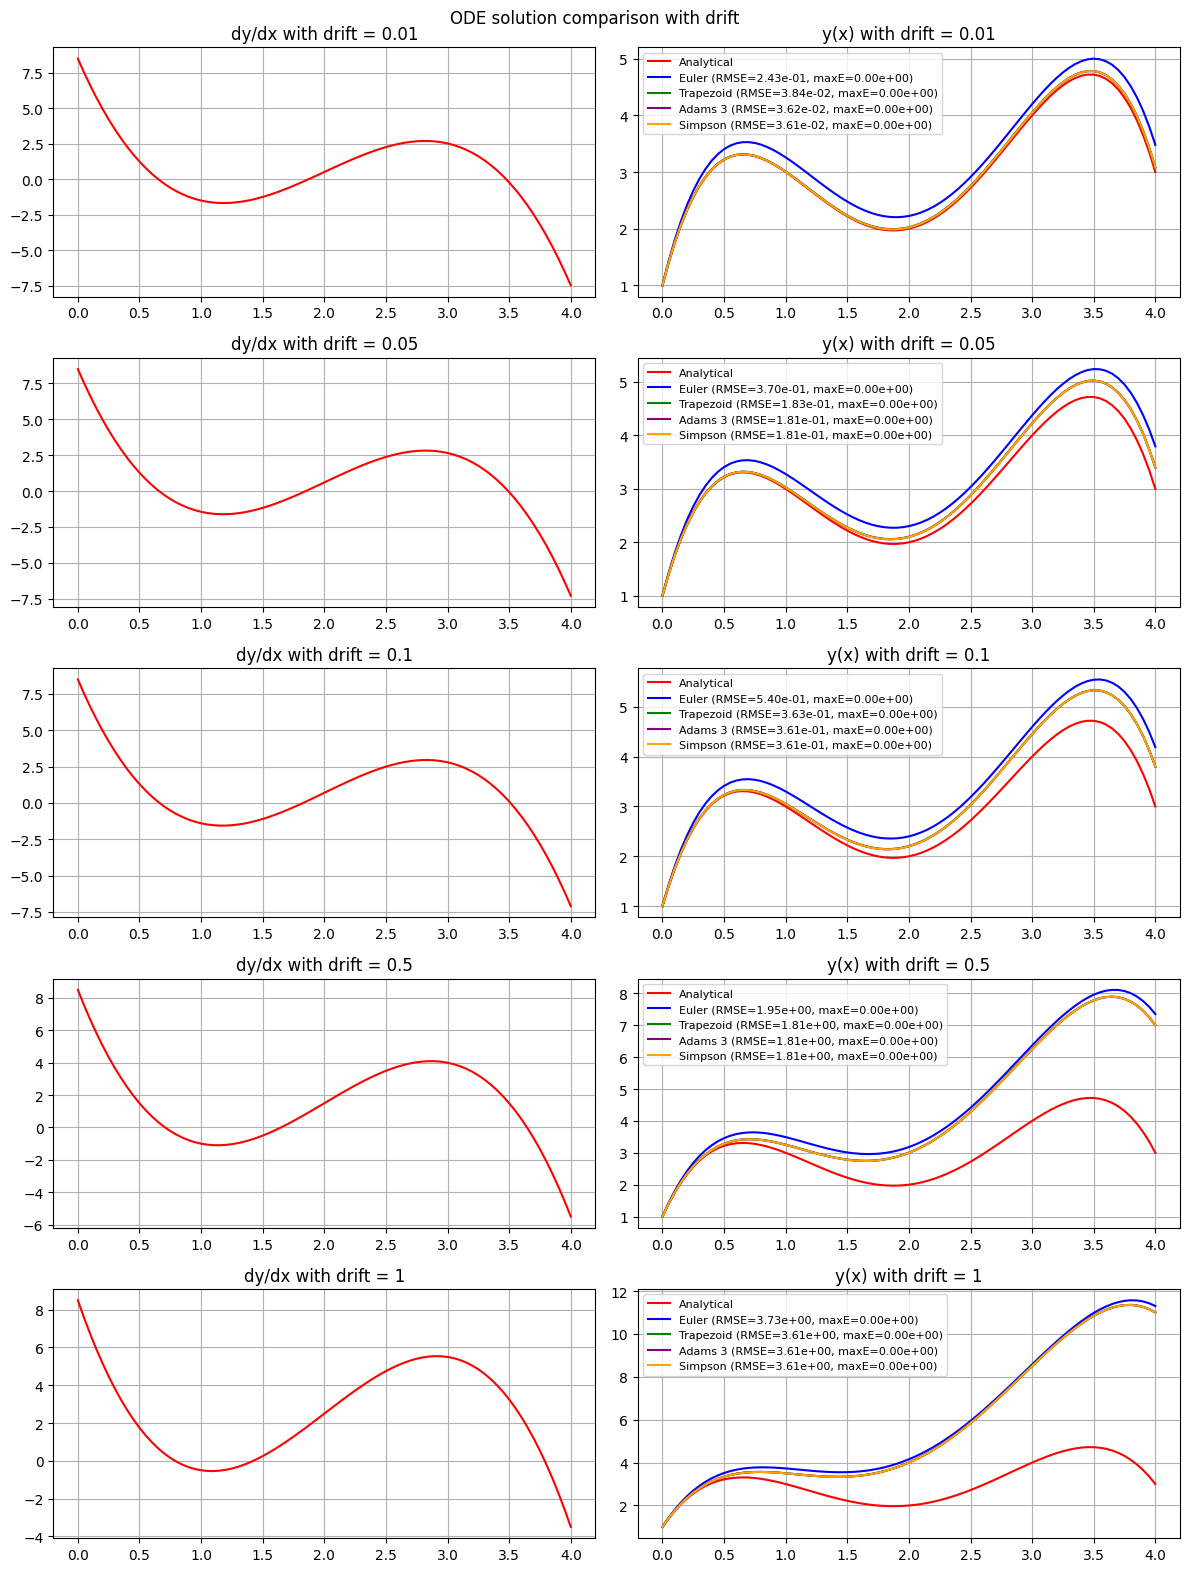

In [5]:
driftSlopes = [0.01, 0.05, 0.1, 0.5, 1]
fig, axes = plt.subplots(len(driftSlopes), 2, figsize=(12, 16))
fig.suptitle("ODE solution comparison with drift")
for j, slope in enumerate(driftSlopes):
    dyDrifted = a + slope * t
    axes[j, 0].plot(t, dyDrifted, color="red")
    axes[j, 0].set_title(f"dy/dx with drift = {slope}")
    axes[j, 0].grid()
    plotODESolutions(
        axes[j, 1], f"y(x) with drift = {slope}", t, dt, x0, v, dyDrifted, y0
    )
fig.tight_layout()
plt.show()

## Real ODEs: IMU captures


Without some correction strategy, velocity will drift away fast (in the order of $10^1s$) and hard (in the order of $10^0-10^1$ m/s) from zero even if the device is not moving across space. The general approach is to make velocity approach zero (ZUPT, zero velocity update) during stationary periods. There are many ways to try to achieve this.

A preliminary step that can be combined with ZUPTs is to use the same online bias mitigation technique used for the gyroscope in the [calibration](../1-calibration/1-analysis.ipynb) notebook. Everytime stationality is detected, observe the current gravity-free acceleration and use it to update the bias estimate:
$$
\mathbf{b}_{a,i} =
\begin{cases}
\alpha_{a} \mathbf{b}_{a,i-1} + (1-\alpha_{a})\mathbf{a}_{i}, & \text{if stationary} \\
\mathbf{b}_{a,i-1}, & \text{otherwise}
\end{cases}
$$
Where $\mathbf{b}_{a,0}$ is an initial bias computed from the gravity-free stationary captures. 
Then use:
$$
\mathbf{a}_{corr,i} = \mathbf{a}_{i} - \mathbf{b}_{a,i}
$$
For simplicity make $\alpha_{a}$ = $\alpha_{\omega}$, the same smoothing factor used for the gyroscope. 

A first option for ZUPT is to use a hard-gated exponential decay during stationary periods, otherwise regular trapezoid integration: 
$$
\mathbf{v}_i = \alpha_{v} \cdot (\mathbf{v}_{i-1} + \frac{\Delta t}{2}\left(\mathbf{a}_{i-1} + \mathbf{a}_i\right)) \\
$$
During stationary periods, $0 \leq \alpha_{v} < 1$, otherwise $\alpha_{v} = 1$. Notice that during stationary periods, instead of just using $v_{i-1}$, the integral is still performed but attenuated, so that the actual dynamics is not completely lost.

A second option is to, instead of detecting stationality globally with all acceleration and gyroscope values, make axis-wise updates. This makes sense because complete stillness is not as likely during real movements as movement performed primarily in one direction, giving more opportunities to apply ZUPT and avoid trending behavior in the velocity. The update is the same as above, but applied to each axis independently:
$$
v_{i, j} = \alpha_{v} \cdot (v_{i-1, j} + \frac{\Delta t}{2}\left(a_{i-1, j} + a_{i, j}\right)) \\
$$
When $\mu_{a,j} - k \sigma_{a,j} \leq a_{i,j} \leq \mu_{a,j} + k \sigma_{a,j}$, $\alpha_{v}$ is in the range $0 \leq \alpha_{v} < 1$, and otherwise $\alpha_{v} = 1$.

A third option is to migrate from a hard-gated or step-like $\alpha_{v}$ to a non-linear continuous model. First, a residual can be defined:
$$
r_{i,j} = \frac{a_{i,j} - \mu_{a,j}}{k \sigma_{a,j}}
$$
Where $\mu_{a,j}$ and $\sigma_{a,j}$ are the mean and standard deviation of the acceleration along axis $j$ derived from stationary captures, and $k$ is a tolerance factor similar to the one used in `IMUSampleChecker`. Then, exponential decay can be applied to the residual to obtain a confidence value:
$$
c_{i,j} = \exp(-\beta r_{i,j}^2)
$$
When perfect stationarity is detected ($r_{i,j} = 0$), the confidence is maximal ($c_{i,j} = 1$). When $r_{i,j} \to \infty$, the confidence approaches zero ($c_{i,j} \to 0$). Then define:
$$
\gamma_{i,j} = 1 - (1 - \alpha_v)c_{i,j}
$$
Now when perfect stationarity is detected, $\gamma_{i,j} = \alpha_v$, and when $r_{i,j} \to \infty$, $\gamma_{i,j} = 1$. This gives a smooth transition between the two extremes. Lastly, apply the update:
$$
v_{i, j} = \gamma_{i,j} \cdot (v_{i-1, j} + \frac{\Delta t}{2}\left(a_{i-1, j} + a_{i, j}\right)) \\
$$

In [6]:
ALPHA_A = 0.967216
AXIS_STD_TOL = 3

rawAccels = np.vstack(
    [reader.readWithOrientation(capture)[1] for capture in stationaryCaptures]
)
aStationaryMean = np.mean(rawAccels, axis=0)
aStationaryStd = np.std(rawAccels, axis=0)

axesLabels = ["ax", "ay", "az"]
for j, label in enumerate(axesLabels):
    print(
        f"{axesLabels[j]}: "
        f"\n\tbias = {aStationaryMean[j]:.6f}, "
        f"\n\tstd = {aStationaryStd[j]:.6f}, "
        f"\n\tTolerance interval: "
        f"[{aStationaryMean[j] - AXIS_STD_TOL * aStationaryStd[j]:.6f}, {aStationaryMean[j] + AXIS_STD_TOL * aStationaryStd[j]:.6f}]"
    )


def calibrateAccelOnline(a, w):
    aBias = np.zeros((len(w), 3))
    aBias[0, :] = aStationaryMean
    stationaryFlags = stationaryChecker.areStationarySamples(a, w)
    for i in range(1, len(w)):
        isStationary = stationaryFlags[i]
        if isStationary:
            aBias[i, :] = ALPHA_A * aBias[i - 1, :] + (1 - ALPHA_A) * a[i, :]
        else:
            aBias[i, :] = aBias[i - 1, :]
    return a - aBias

ax: 
	bias = 0.024850, 
	std = 0.061480, 
	Tolerance interval: [-0.159591, 0.209290]
ay: 
	bias = -0.005075, 
	std = 0.046824, 
	Tolerance interval: [-0.145548, 0.135398]
az: 
	bias = 0.009261, 
	std = 0.044466, 
	Tolerance interval: [-0.124136, 0.142658]


In [7]:
def cumulativeTrapezoidRaw(a, w, t, dt):
    return integrate.cumulative_trapezoid(a, x=t, dx=dt, initial=0, axis=0)


ALPHA_V = ALPHA_A * 5 / 6


def cumulativeTrapezoidGlobalHardZUPT(a, w, t, dt):
    v = np.zeros_like(a)
    for i in range(1, len(a)):
        v[i, :] = v[i - 1, :] + (a[i - 1, :] + a[i, :]) * dt / 2
        if stationaryChecker.isStationarySample(
            a[i, 0], a[i, 1], a[i, 2], w[i, 0], w[i, 1], w[i, 2]
        ):
            v[i, :] *= ALPHA_V
    return v


def cumulativeTrapezoidAxisWiseHardZUPT(a, w, t, dt):
    v = np.zeros_like(a)
    for i in range(1, len(a)):
        v[i, :] = v[i - 1, :] + (a[i - 1, :] + a[i, :]) * dt / 2
        for j in range(3):
            if abs(a[i, j] - aStationaryMean[j]) < AXIS_STD_TOL * aStationaryStd[j]:
                v[i, j] *= ALPHA_V
    return v


def cumulativeTrapezoidAxisWiseSoftZUPT(a, w, t, dt):
    v = np.zeros_like(a)
    BETA = 2.0
    for i in range(1, len(a)):
        v[i, :] = v[i - 1, :] + (a[i - 1, :] + a[i, :]) * dt / 2
        for j in range(3):
            normalizedResidual = (a[i, j] - aStationaryMean[j]) / (
                AXIS_STD_TOL * aStationaryStd[j] + 1e-12
            )  # Add a small value to avoid division by zero
            confidence = np.exp(-BETA * normalizedResidual**2)
            gamma = 1.0 - (1.0 - ALPHA_V) * confidence
            v[i, j] *= gamma
    return v

In [8]:
def plotVelocitySeries(captures):
    cols = 3
    rows = len(captures)

    fig, axes = plt.subplots(rows, cols, squeeze=False, figsize=(8 * cols, 4 * rows))
    fig.suptitle(
        "Velocity estimation comparison",
        fontsize=16,
    )

    for captureIdx, capture in enumerate(captures):
        seq, a, w, _ = reader.readWithOrientation(capture)
        t = seq * dt
        v0 = np.array([0.0, 0.0, 0.0])
        aOnline = calibrateAccelOnline(a, w)

        vRegular = v0 + cumulativeTrapezoidRaw(a, w, t, dt)
        vAccelOnline = v0 + cumulativeTrapezoidRaw(aOnline, w, t, dt)
        vAccelOnlineGlobalHardZUPT = v0 + cumulativeTrapezoidGlobalHardZUPT(
            aOnline, w, t, dt
        )
        vAccelOnlineAxiswiseHardZUPT = v0 + cumulativeTrapezoidAxisWiseHardZUPT(
            aOnline, w, t, dt
        )
        vAccelOnlineAxiswiseSoftZUPT = v0 + cumulativeTrapezoidAxisWiseSoftZUPT(
            aOnline, w, t, dt
        )

        globalStationaryIntervals = stationaryChecker.findStationaryIntervals(seq, a, w)
        axisStationaryIntervals = findAxisWiseStationaryIntervals(seq, a, w)

        axes[captureIdx][1].set_title(f"{capture}")
        vLabel = ["vx (m/s)", "vy (m/s)", "vz (m/s)"]
        for j in range(3):
            axis = axes[captureIdx][j]
            axis.plot(t, vRegular[:, j], label="Raw trapezoid", color="blue")
            axis.plot(t, vAccelOnline[:, j], label="Online a", color="green")
            axis.plot(
                t,
                vAccelOnlineGlobalHardZUPT[:, j],
                label="Online a + global hard ZUPT",
                color="red",
            )
            axis.plot(
                t,
                vAccelOnlineAxiswiseHardZUPT[:, j],
                label="Online a + axis-wise hard ZUPT",
                color="orange",
            )
            axis.plot(
                t,
                vAccelOnlineAxiswiseSoftZUPT[:, j],
                label="Online a + axis-wise soft ZUPT",
                color="purple",
            )
            axis.axhline(0, color="black", linestyle="-", linewidth=1)
            axis.set_xlabel("t (s)")
            axis.set_ylabel(vLabel[j])
            axis.legend()
            axis.grid(color="black", linestyle="-", linewidth=1, alpha=1)

            for lower, upper in globalStationaryIntervals:
                axis.axvspan(
                    lower * dt, upper * dt, color="tab:gray", alpha=0.5, zorder=0
                )
            for lower, upper in axisStationaryIntervals[j]:
                axis.axvspan(
                    lower * dt, upper * dt, color="tab:gray", alpha=0.25, zorder=0
                )

    fig.tight_layout(rect=(0, 0, 1, 0.985))
    plt.show()


def findAxisWiseStationaryIntervals(seq, a, w):
    stationaryFlags = np.zeros((len(seq), 3), dtype=bool)
    for i in range(len(seq)):
        for j in range(3):
            stationaryFlags[i, j] = abs(a[i, j] - aStationaryMean[j]) < (
                AXIS_STD_TOL * aStationaryStd[j]
            )

    axisWiseIntervals = []
    for j in range(3):
        wasStationary = stationaryFlags[0, j]
        lastLowerBound = int(seq[0])
        stationaryIntervals = []
        for i, isStationary in enumerate(stationaryFlags[1:, j], start=1):
            if wasStationary and not isStationary:
                stationaryIntervals.append((lastLowerBound, int(seq[i - 1])))
                wasStationary = False
            if not wasStationary and isStationary:
                lastLowerBound = int(seq[i])
                wasStationary = True

        if wasStationary:
            stationaryIntervals.append((lastLowerBound, int(seq[-1])))

        axisWiseIntervals.append(stationaryIntervals)

    return axisWiseIntervals

### Stationary captures

Raw integration diverges quickly as expected. Online acceleration calibration stabilizes the velocity asymptotically but leaves a residual value different from zero. All ZUPT approaches work well. 

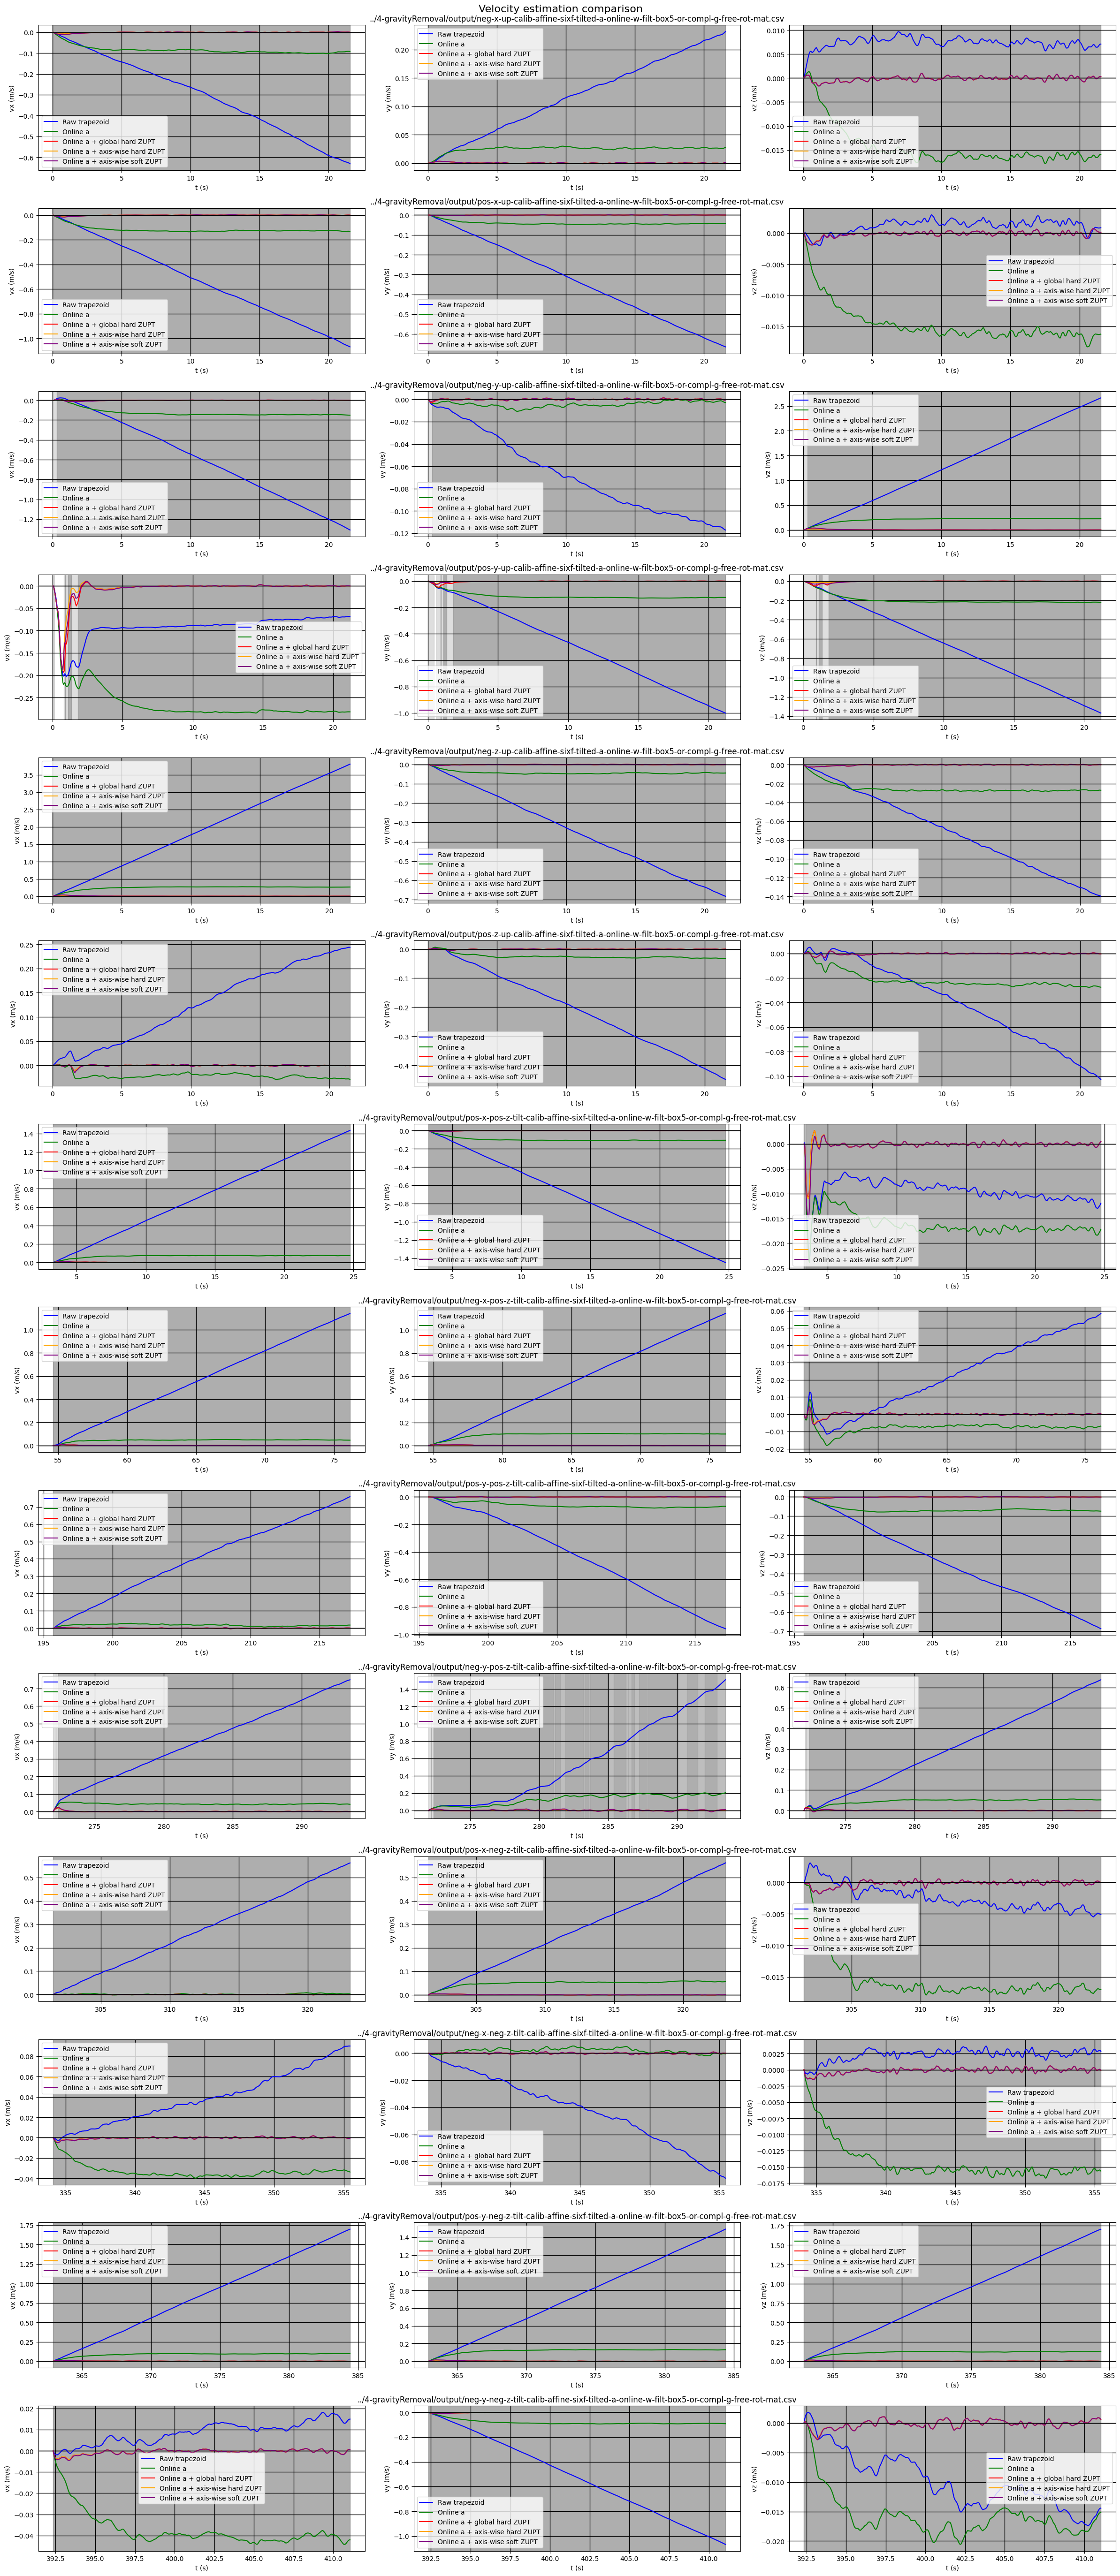

In [9]:
plotVelocitySeries(stationaryCaptures)

### Simple rotations captures

The online acceleration calibration tends to display the same shape as the raw integration, but with a different "trajectory". All ZUPT approaches still work as they make the velocity approach zero quickly and keep the amplitude at reasonable values.

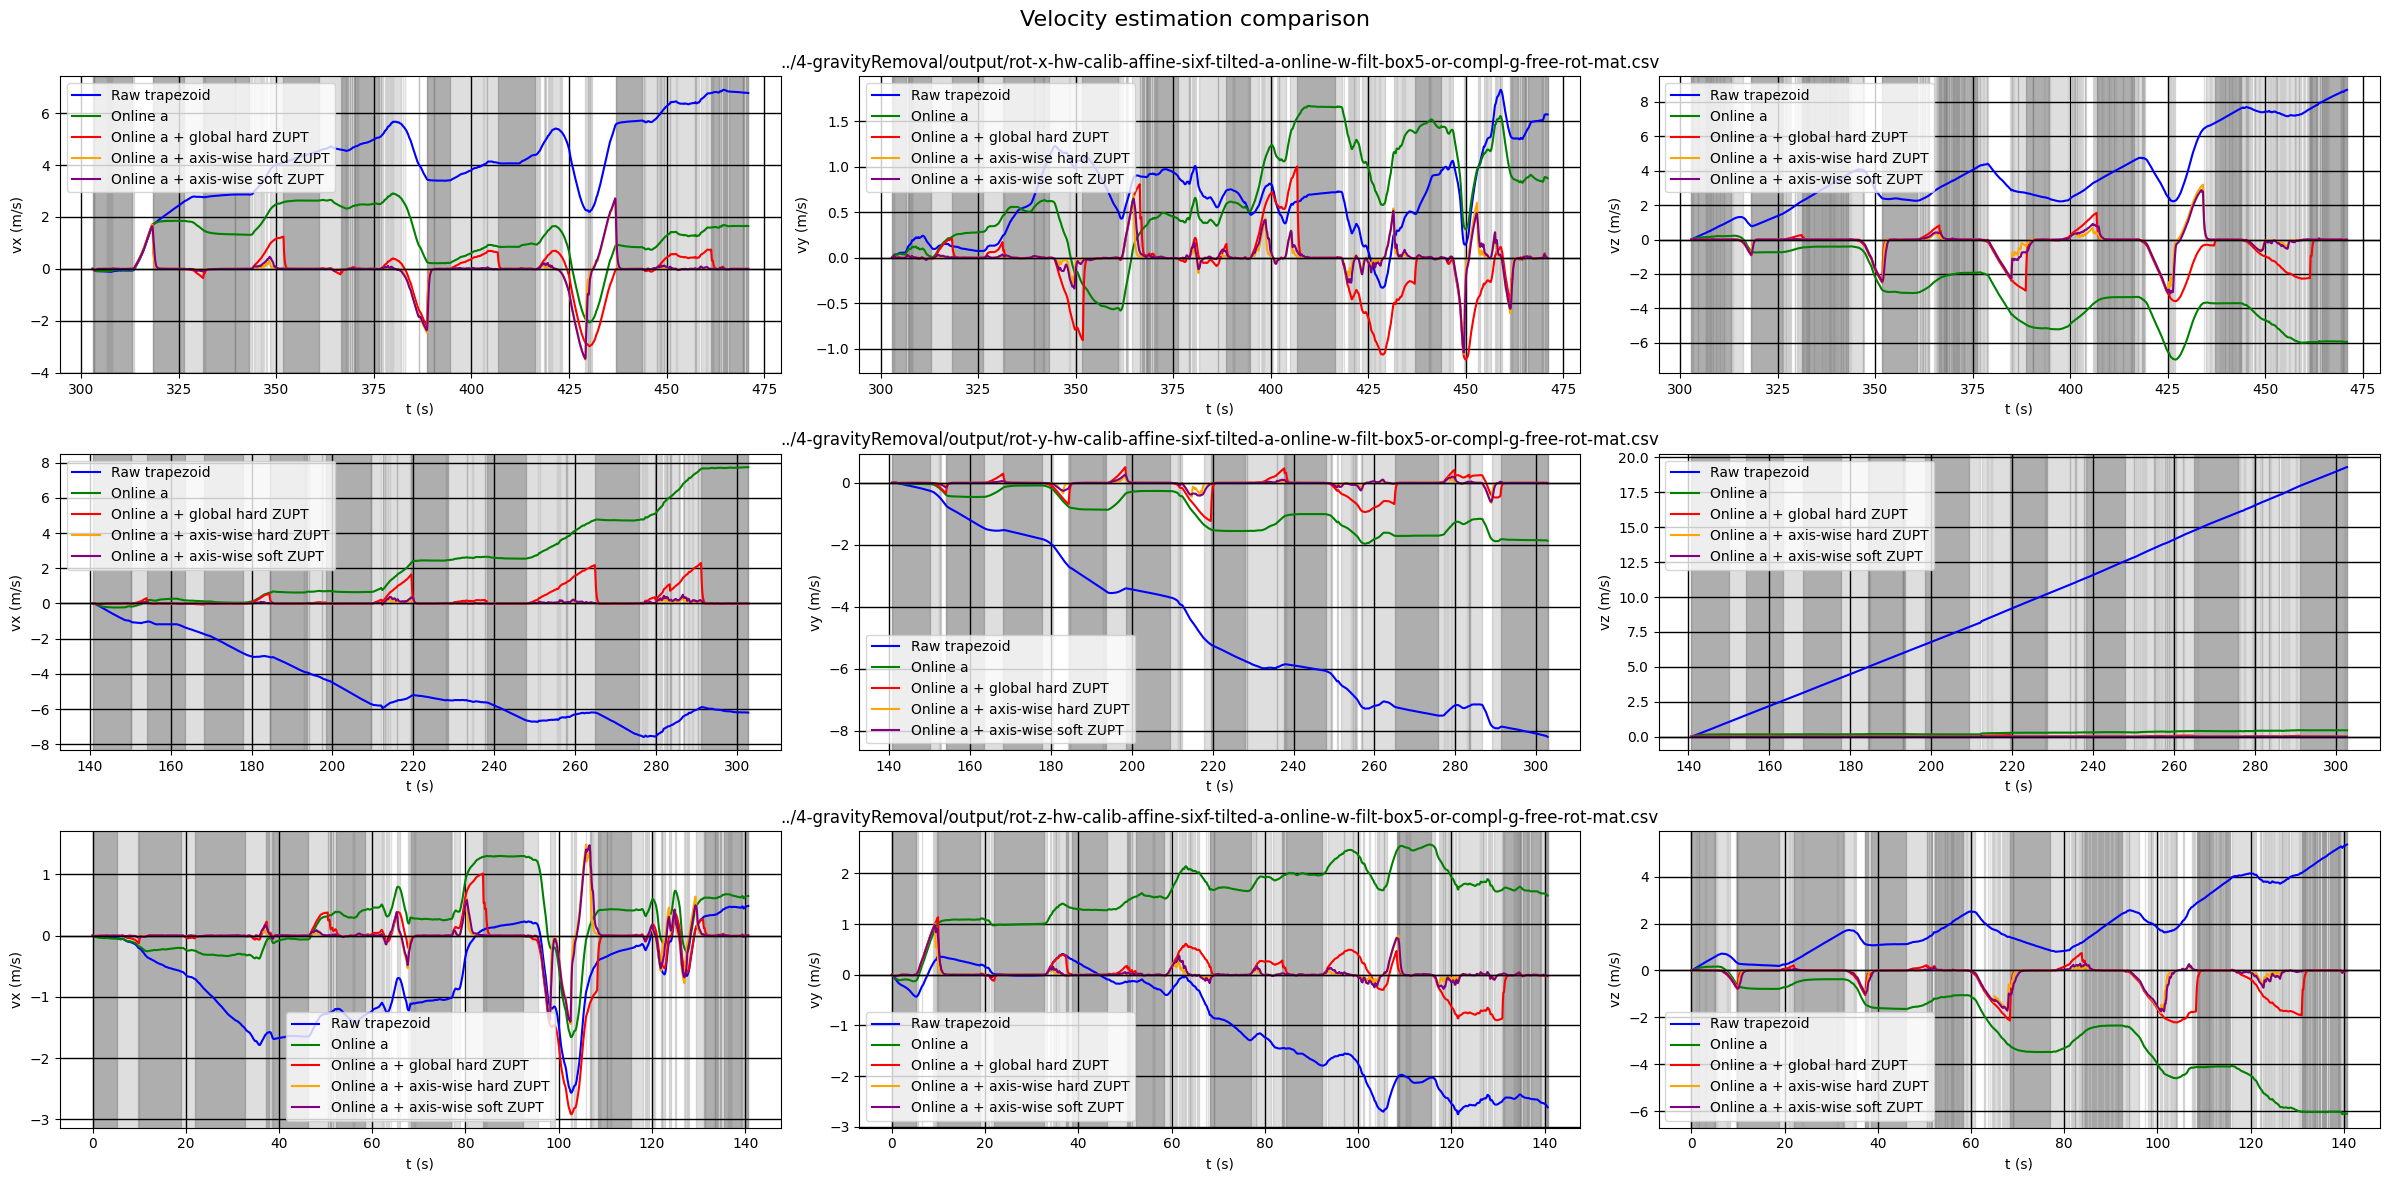

In [10]:
plotVelocitySeries(simpleRotationsCaptures)

### Real captures

The velocity estimation is much more strained. Real exercise sets are longer, lasting between 30s and 1min, and there aren't as many pure stationary intervals. 

Raw integration and online acceleration calibration just don't work.

In the global ZUPT approach:
* Sharp changes in velocity are observed. While this is not that physically realistic since it would represent an acceleration that tends to infinity, $\alpha_{v}$ could be fine-tuned if needed. 
* There are still upward or downward trends, as ZUPT opportunities are sparse.
* Probably unrealistic values are still observed (e.g. >=10 m/s = 36 km/h).

Both axis-wise ZUPT approaches work and look similar. While the soft one may be better, it's harder to reason about and tune, as well as more computationally expensive. The hard-gated one is simpler and works well enough. 

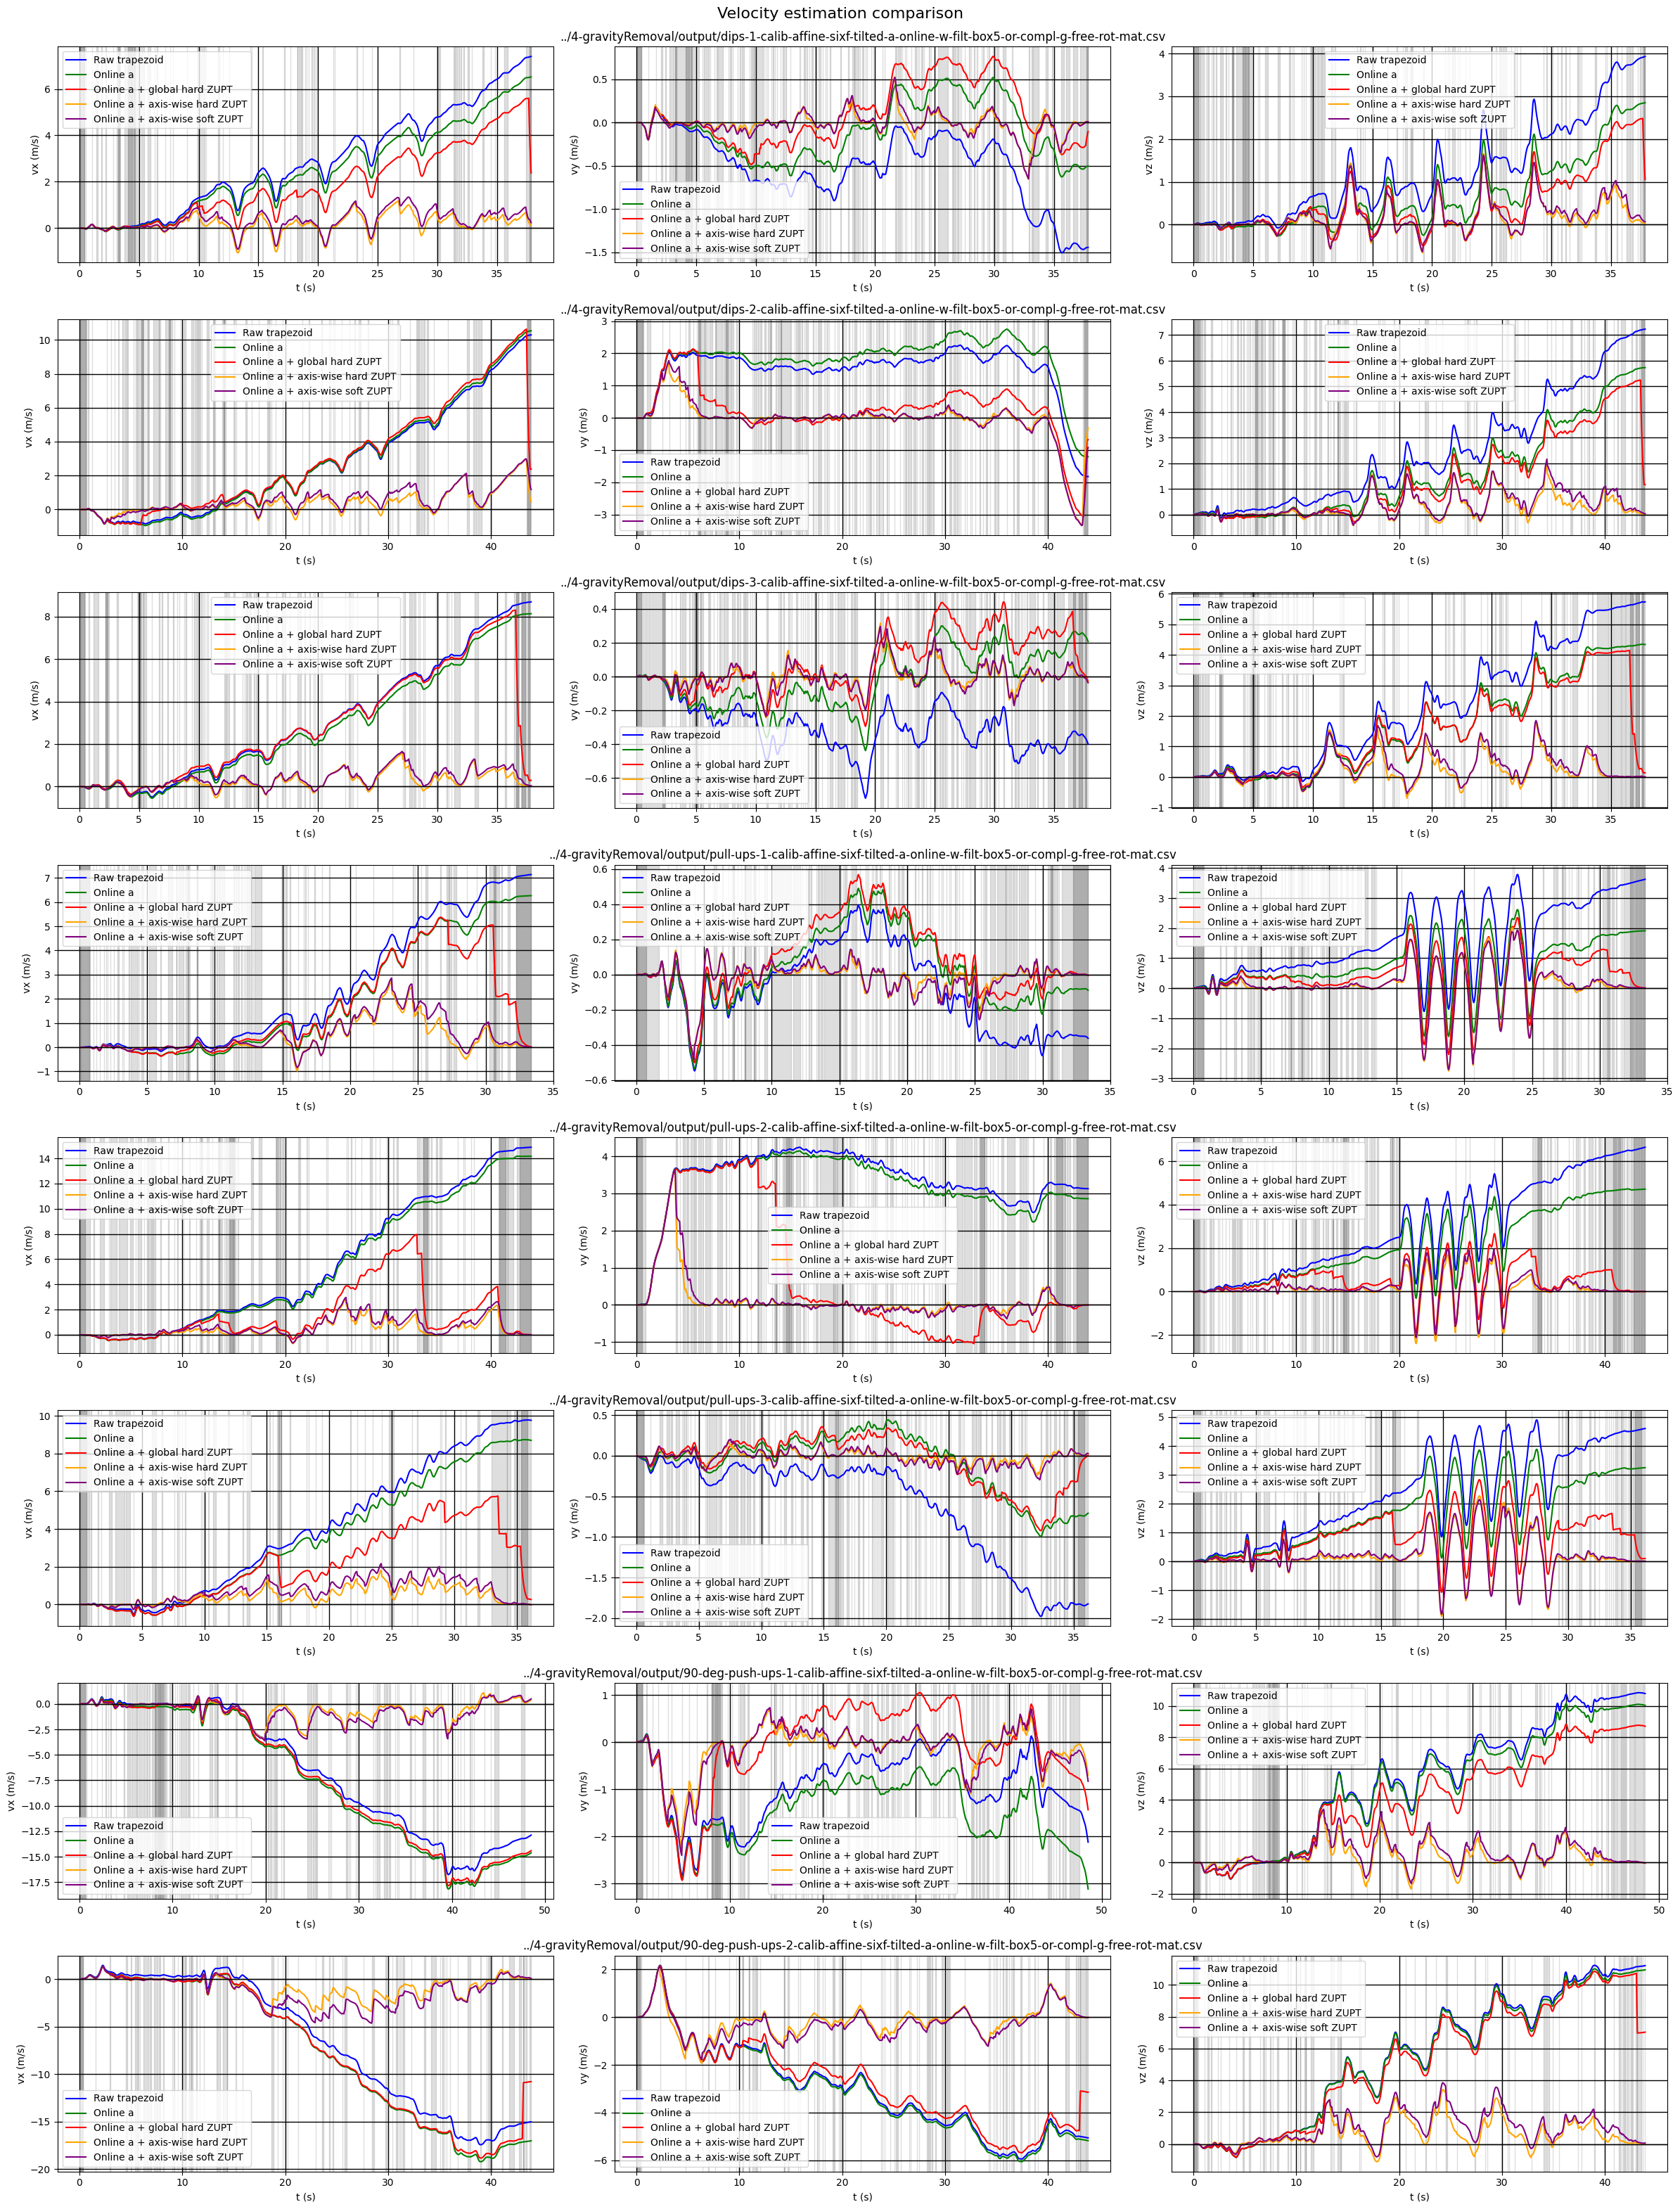

In [11]:
plotVelocitySeries(exerciseCaptures)

## Last sanity check: derivative behavior

$a_{j} = \frac{dv_{j}}{dt}$ evaluated against $v_{j}$ verifies that:
* When $v$ reaches a local maximum or minimum, $a$ stays close to zero.
* When $v$ is increasing, $a$ is positive, and when $v$ is decreasing, $a$ is negative. 

For acceleration, online calibration was used. For velocity, hard-gated axis-wise ZUPT on the calibrated acceleration was used.

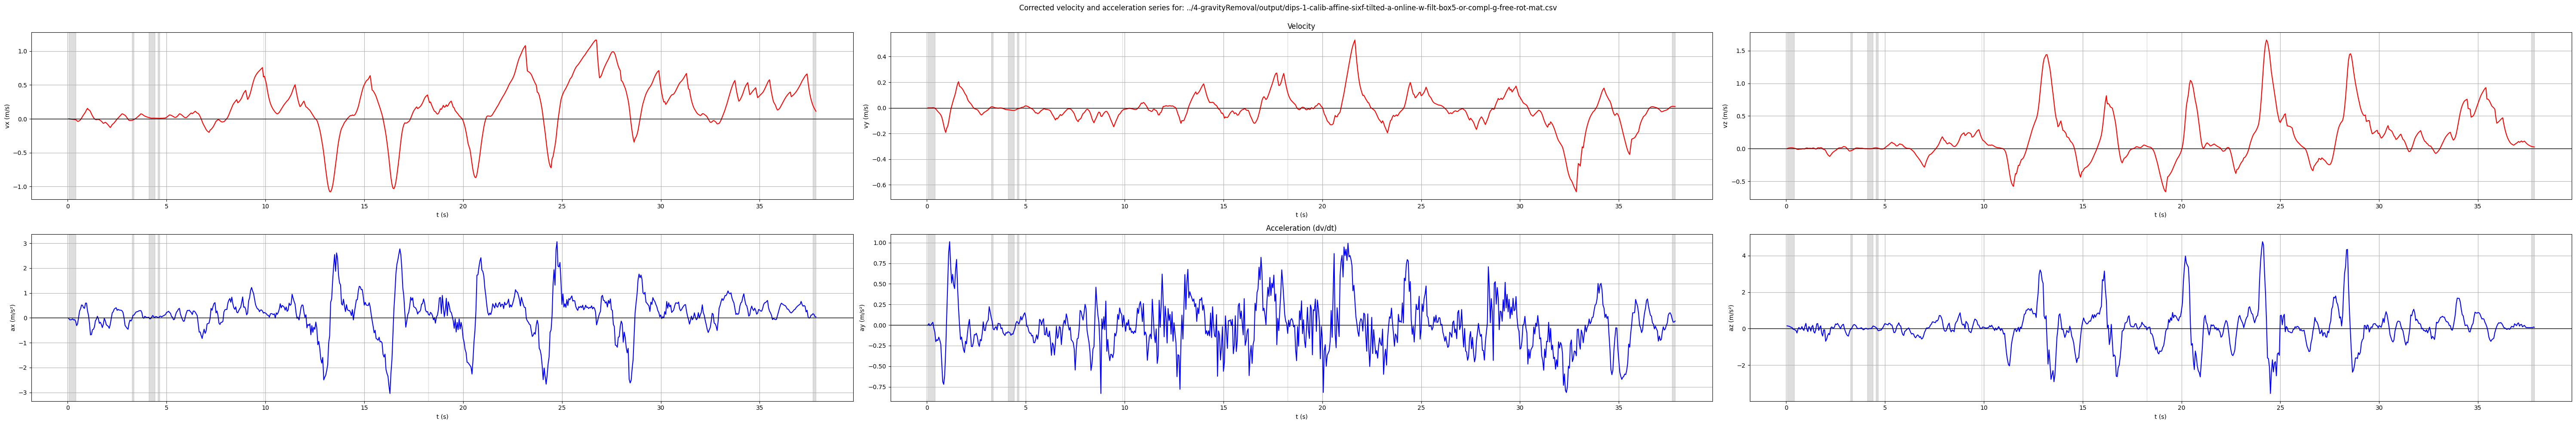

In [12]:
CHOSEN_CAPTURE = exerciseCaptures[0]


def plotVelocityAndAccelerationSeries(capture):
    fig, axes = plt.subplots(2, 3, figsize=(60, 10))
    fig.suptitle(
        f"Corrected velocity and acceleration series for: {capture}",
    )
    seq, a, w, _ = reader.readWithOrientation(capture)
    t = seq * dt
    v0 = np.array([0.0, 0.0, 0.0])
    aOnline = calibrateAccelOnline(a, w)
    v = v0 + cumulativeTrapezoidAxisWiseHardZUPT(aOnline, w, t, dt)

    stationaryIntervals = stationaryChecker.findStationaryIntervals(seq, a, w)

    axes[0, 1].set_title(f"Velocity")
    axes[1, 1].set_title(f"Acceleration (dv/dt)")
    vLabels = ["vx (m/s)", "vy (m/s)", "vz (m/s)"]
    aLabels = ["ax (m/s²)", "ay (m/s²)", "az (m/s²)"]
    for j in range(3):
        axes[0, j].plot(t, v[:, j], color="red")
        axes[0, j].set_xlabel("t (s)")
        axes[0, j].set_ylabel(vLabels[j])
        axes[0, j].grid()
        axes[0, j].axhline(0, color="black", linestyle="-", linewidth=1)

        axes[1, j].plot(t, aOnline[:, j], color="blue")
        axes[1, j].set_xlabel("t (s)")
        axes[1, j].set_ylabel(aLabels[j])
        axes[1, j].grid()
        axes[1, j].axhline(0, color="black", linestyle="-", linewidth=1)

        for lower, upper in stationaryIntervals:
            axes[0, j].axvspan(
                lower * dt, upper * dt, color="tab:gray", alpha=0.25, zorder=0
            )
            axes[1, j].axvspan(
                lower * dt, upper * dt, color="tab:gray", alpha=0.25, zorder=0
            )

    fig.tight_layout(rect=(0, 0, 1, 0.985))
    plt.show()


plotVelocityAndAccelerationSeries(CHOSEN_CAPTURE)

# Conclusion

Use online acceleration calibration paired with axis-wise hard-gated ZUPT for production. Test it on the gym to address whether further refinements are needed or not.

In [13]:
def exportResults(captures):
    for capture in captures:
        seq, a, w, angle = reader.readWithOrientation(capture)
        t = seq * dt
        v0 = np.array([0.0, 0.0, 0.0])
        aOnline = calibrateAccelOnline(a, w)
        v = v0 + cumulativeTrapezoidAxisWiseHardZUPT(aOnline, w, t, dt)

        oldFileName = capture.split("/")[-1].split(".")[0]
        writer.writeWithVelocity(
            f"./output/{oldFileName}-online-a-v-axis-hard-zupt.csv",
            seq,
            a,
            w,
            angle,
            v,
        )


exportResults(stationaryCaptures)
exportResults(simpleRotationsCaptures)
exportResults(exerciseCaptures)